In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from scipy import stats

In [ ]:
df = pd.read_csv("PremierLeague_Merged_Project_Data.csv")

df.head()

,Player,Age,MarketValue,Club,Position,MatchesPlayed,MinutesPlayed,Goals,Assists,xG,xA
0,Tyler Adams,26,€12.00m,AFC Bournemouth,Defensive Midfield,28,1965,0,3,1.6,1.0
1,Tosin Adarabioyo,27,€15.00m,Chelsea FC,Centre-Back,22,1409,1,1,0.9,0.2
2,Simon Adingra,23,€25.00m,Brighton & Hove Albion,Left Winger,29,1097,2,2,2.5,2.5
3,Emmanuel Agbadou,28,€15.00m,Wolverhampton Wanderers,Centre-Back,16,1410,1,0,0.8,0.2
4,Ola Aina,28,€20.00m,Nottingham Forest,Right-Back,35,2995,2,1,0.6,1.4


In [ ]:
def convert_market_value(value):

    value = value.replace("€", "")

    if "m" in value:
        return float(value.replace("m", ""))

    elif "k" in value:
        return float(value.replace("k", "")) / 1000

    else:
        return float(value)

df["MarketValue"] = df["MarketValue"].apply(convert_market_value)

In [ ]:
print(df["MarketValue"].head())
print(df["MarketValue"].dtype)

0    12.0
1    15.0
2    25.0
3    15.0
4    20.0
Name: MarketValue, dtype: float64
float64


In [ ]:
import numpy as np

df["LogMarketValue"] = np.log(df["MarketValue"])

In [ ]:
df[["MarketValue", "LogMarketValue"]].head()

,MarketValue,LogMarketValue
0,12.0,2.484907
1,15.0,2.708050
2,25.0,3.218876
3,15.0,2.708050
4,20.0,2.995732


In [ ]:
df.describe()

,Age,MarketValue,MatchesPlayed,MinutesPlayed,Goals,Assists,xG,xA,LogMarketValue
count,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000
mean,25.768786,23.605347,23.748555,1589.381503,2.713873,1.913295,2.686416,1.898266,2.656492
std,3.763864,22.949518,10.986833,1020.859597,4.251742,2.576032,3.758517,2.161668,1.174080
min,18.000000,0.150000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-1.897120
25%,23.000000,8.000000,14.250000,668.250000,0.000000,0.000000,0.300000,0.300000,2.079442
50%,26.000000,20.000000,26.000000,1650.000000,1.000000,1.000000,1.200000,1.100000,2.995732
75%,28.000000,30.000000,33.000000,2433.000000,3.000000,3.000000,3.500000,2.900000,3.401197
max,35.000000,180.000000,38.000000,3420.000000,29.000000,18.000000,25.200000,14.200000,5.192957


In [ ]:
df[
    [
        "MarketValue",
        "Age",
        "Goals",
        "Assists",
        "MinutesPlayed",
        "MatchesPlayed",
        "xG",
        "xA"
    ]
].corr()

,MarketValue,Age,Goals,Assists,MinutesPlayed,MatchesPlayed,xG,xA
MarketValue,1.000000,-0.205741,0.472472,0.412337,0.370593,0.336882,0.497107,0.471799
Age,-0.205741,1.000000,0.082975,0.094487,0.290031,0.242023,0.101753,0.091365
Goals,0.472472,0.082975,1.000000,0.581005,0.425696,0.458370,0.950332,0.623723
Assists,0.412337,0.094487,0.581005,1.000000,0.510342,0.541712,0.590033,0.890381
MinutesPlayed,0.370593,0.290031,0.425696,0.510342,1.000000,0.904129,0.446543,0.562583
MatchesPlayed,0.336882,0.242023,0.458370,0.541712,0.904129,1.000000,0.492284,0.598550
xG,0.497107,0.101753,0.950332,0.590033,0.446543,0.492284,1.000000,0.636994
xA,0.471799,0.091365,0.623723,0.890381,0.562583,0.598550,0.636994,1.000000


In [ ]:
import statsmodels.api as sm

y = df["LogMarketValue"]

df["Age2"] = df["Age"] ** 2

In [ ]:
X = df[["Goals"]]

X = sm.add_constant(X)

model1 = sm.OLS(y, X).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     56.21
Date:                Fri, 29 May 2026   Prob (F-statistic):           5.58e-13
Time:                        22:35:33   Log-Likelihood:                -519.80
No. Observations:                 346   AIC:                             1044.
Df Residuals:                     344   BIC:                             1051.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3756      0.070     34.155      0.0

In [ ]:
X = df[
    [
        "Goals",
        "Assists"
    ]
]

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     34.33
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.57e-14
Time:                        22:35:33   Log-Likelihood:                -514.41
No. Observations:                 346   AIC:                             1035.
Df Residuals:                     343   BIC:                             1046.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2886      0.073     31.137      0.0

In [ ]:
X = df[
    [
        "Goals",
        "Assists",
        "Age"
    ]
]

X = sm.add_constant(X)

model3 = sm.OLS(y, X).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     44.52
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.59e-24
Time:                        22:35:33   Log-Likelihood:                -488.94
No. Observations:                 346   AIC:                             985.9
Df Residuals:                     342   BIC:                             1001.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9858      0.373     13.383      0.0

In [ ]:
X = df[
    [
        "Goals",
        "Assists",
        "Age",
        "MinutesPlayed"
    ]
]

X = sm.add_constant(X)

model4 = sm.OLS(y, X).fit()

print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     52.37
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.28e-34
Time:                        22:35:33   Log-Likelihood:                -463.13
No. Observations:                 346   AIC:                             936.3
Df Residuals:                     341   BIC:                             955.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.2043      0.348     14.976

In [ ]:
X = df[
    [
        "Goals",
        "Assists",
        "Age",
        "Age2",
        "MinutesPlayed"
    ]
]

X = sm.add_constant(X)

model5 = sm.OLS(y, X).fit()

print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     70.25
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.54e-50
Time:                        22:35:34   Log-Likelihood:                -423.23
No. Observations:                 346   AIC:                             858.5
Df Residuals:                     340   BIC:                             881.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -11.3650      1.791     -6.344

In [ ]:
import pandas as pd

comparison = pd.DataFrame(
{
    "Model":
    [
        "Model 1",
        "Model 2",
        "Model 3",
        "Model 4",
        "Model 5"
    ],

    "R2":
    [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared,
        model5.rsquared
    ],

    "Adjusted_R2":
    [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj,
        model5.rsquared_adj
    ]
}
)

comparison = comparison.sort_values(
    by="Adjusted_R2",
    ascending=False
)

print(comparison)

     Model        R2  Adjusted_R2
4  Model 5  0.508125     0.500892
3  Model 4  0.380526     0.373260
2  Model 3  0.280852     0.274544
1  Model 2  0.166783     0.161924
0  Model 1  0.140455     0.137957


In [ ]:
X = df[
    [
        "xG",
        "xA",
        "Age",
        "Age2",
        "MinutesPlayed"
    ]
]

X = sm.add_constant(X)

model6 = sm.OLS(y, X).fit()

print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     71.41
Date:                Fri, 29 May 2026   Prob (F-statistic):           6.18e-51
Time:                        22:35:34   Log-Likelihood:                -421.78
No. Observations:                 346   AIC:                             855.6
Df Residuals:                     340   BIC:                             878.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -10.9708      1.790     -6.129

In [ ]:
X = df[
    [
        "Goals",
        "Assists",
        "Age",
        "Age2",
        "MinutesPlayed",
        "MatchesPlayed"
    ]
]

X = sm.add_constant(X)

model7 = sm.OLS(y, X).fit()

print(model7.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     58.63
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.53e-49
Time:                        22:35:34   Log-Likelihood:                -422.83
No. Observations:                 346   AIC:                             859.7
Df Residuals:                     339   BIC:                             886.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -11.3347      1.792     -6.324

In [ ]:
print(df["Position"].value_counts())

Position
Centre-Back           66
Central Midfield      41
Centre-Forward        39
Defensive Midfield    34
Right Winger          33
Left Winger           30
Right-Back            27
Left-Back             27
Attacking Midfield    24
Goalkeeper            21
Second Striker         2
Right Midfield         1
Left Midfield          1
Name: count, dtype: int64


In [ ]:
df_pos = pd.get_dummies(
    df,
    columns=["Position"],
    drop_first=True
)

In [ ]:
[c for c in df_pos.columns if c.startswith("Position_")]

['Position_Central Midfield',
 'Position_Centre-Back',
 'Position_Centre-Forward',
 'Position_Defensive Midfield',
 'Position_Goalkeeper',
 'Position_Left Midfield',
 'Position_Left Winger',
 'Position_Left-Back',
 'Position_Right Midfield',
 'Position_Right Winger',
 'Position_Right-Back',
 'Position_Second Striker']

In [ ]:
df_pos.dtypes

,0
Player,object
Age,int64
MarketValue,float64
Club,object
MatchesPlayed,int64
MinutesPlayed,int64
Goals,int64
Assists,int64
xG,float64
xA,float64


In [ ]:
df_pos = pd.get_dummies(
    df,
    columns=["Position"],
    drop_first=True,
    dtype=int
)

In [ ]:
position_cols = [
    c for c in df_pos.columns
    if c.startswith("Position_")
]

X = df_pos[
    [
        "Goals",
        "Assists",
        "Age",
        "Age2",
        "MinutesPlayed"
    ] + position_cols
]

X = sm.add_constant(X)

model8 = sm.OLS(y, X).fit()

print(model8.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     21.37
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.30e-43
Time:                        22:35:34   Log-Likelihood:                -416.98
No. Observations:                 346   AIC:                             870.0
Df Residuals:                     328   BIC:                             939.2
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
position_cols = [
    c for c in df_pos.columns
    if c.startswith("Position_")
]

X = df_pos[
    [
        "Goals",
        "Assists",
        "Age",
        "Age2",
        "MinutesPlayed"
    ] + position_cols
]

X = sm.add_constant(X)

model8 = sm.OLS(y, X).fit()

print(model8.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     21.37
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.30e-43
Time:                        22:35:34   Log-Likelihood:                -416.98
No. Observations:                 346   AIC:                             870.0
Df Residuals:                     328   BIC:                             939.2
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
comparison = pd.DataFrame(
{
    "Model":
    [
        "Model1",
        "Model2",
        "Model3",
        "Model4",
        "Model5",
        "Model6",
        "Model7",
        "Model8"
    ],

    "R2":
    [
        model1.rsquared,
        model2.rsquared,
        model3.rsquared,
        model4.rsquared,
        model5.rsquared,
        model6.rsquared,
        model7.rsquared,
        model8.rsquared
    ],

    "Adj_R2":
    [
        model1.rsquared_adj,
        model2.rsquared_adj,
        model3.rsquared_adj,
        model4.rsquared_adj,
        model5.rsquared_adj,
        model6.rsquared_adj,
        model7.rsquared_adj,
        model8.rsquared_adj
    ]
}
)

comparison.sort_values(
    by="Adj_R2",
    ascending=False
)

,Model,R2,Adj_R2
5,Model6,0.512229,0.505056
7,Model8,0.525568,0.500979
4,Model5,0.508125,0.500892
6,Model7,0.509257,0.500571
3,Model4,0.380526,0.373260
2,Model3,0.280852,0.274544
1,Model2,0.166783,0.161924
0,Model1,0.140455,0.137957


In [ ]:
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:         LogMarketValue   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     71.41
Date:                Fri, 29 May 2026   Prob (F-statistic):           6.18e-51
Time:                        22:35:34   Log-Likelihood:                -421.78
No. Observations:                 346   AIC:                             855.6
Df Residuals:                     340   BIC:                             878.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -10.9708      1.790     -6.129

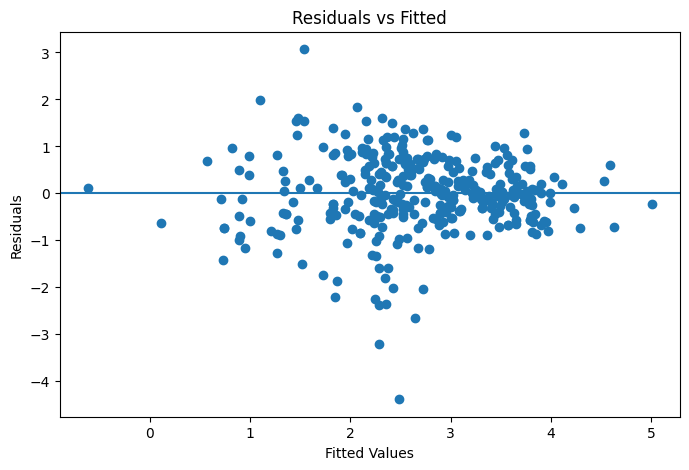

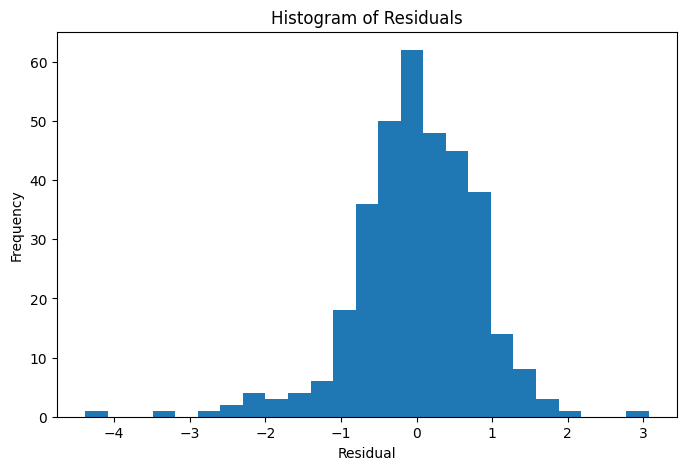

In [ ]:
best_model = model6

residuals = best_model.resid

fitted = best_model.fittedvalues

plt.figure(figsize=(8,5))

plt.scatter(fitted, residuals)

plt.axhline(y=0)

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted")

plt.show()

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=25)

plt.title("Histogram of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

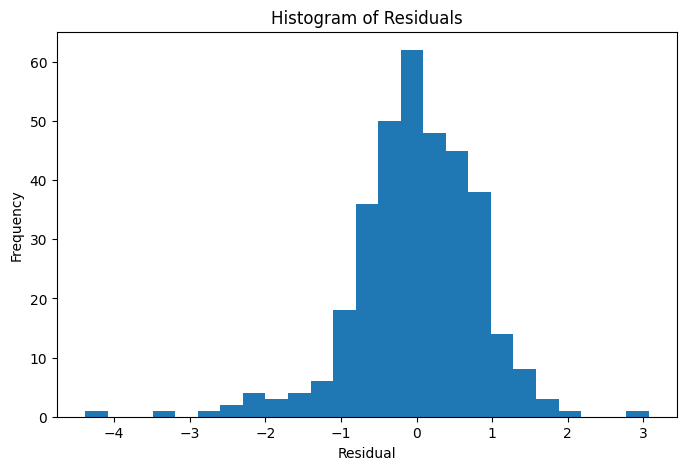

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=25)

plt.title("Histogram of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

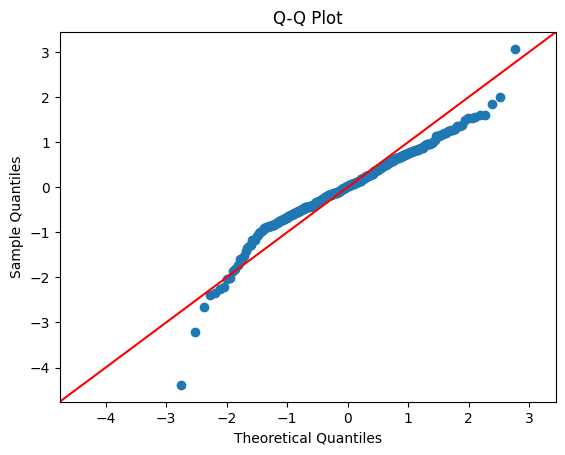

In [ ]:
sm.qqplot(
    residuals,
    line='45'
)

plt.title("Q-Q Plot")

plt.show()

In [ ]:
print("Residual Mean =", residuals.mean())

Residual Mean = 1.740675683233107e-14


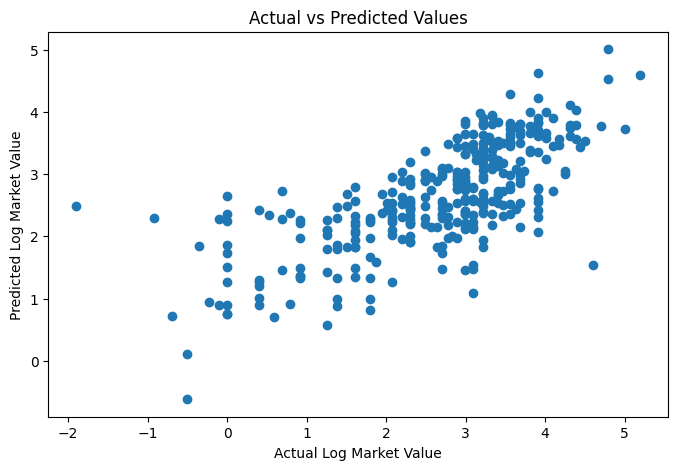

In [ ]:
predicted = best_model.predict()

plt.figure(figsize=(8,5))

plt.scatter(
    y,
    predicted
)

plt.xlabel("Actual Log Market Value")

plt.ylabel("Predicted Log Market Value")

plt.title("Actual vs Predicted Values")

plt.show()

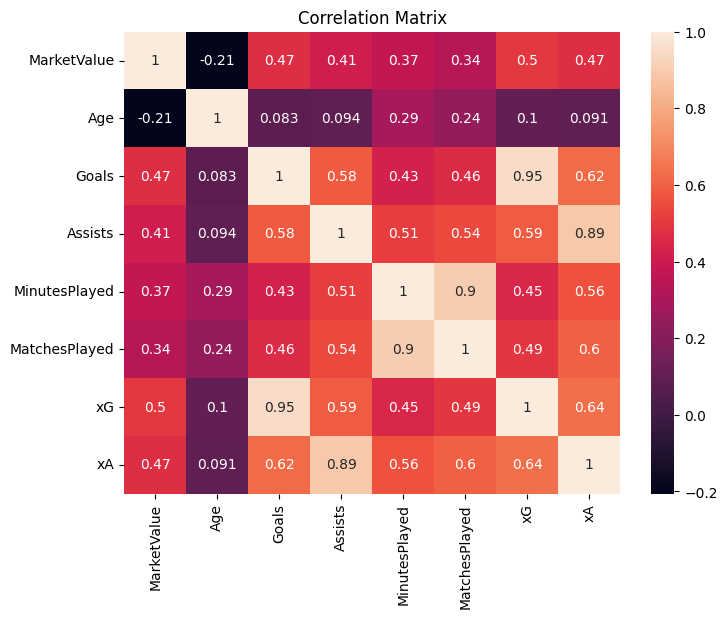

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            "MarketValue",
            "Age",
            "Goals",
            "Assists",
            "MinutesPlayed",
            "MatchesPlayed",
            "xG",
            "xA"
        ]
    ].corr(),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

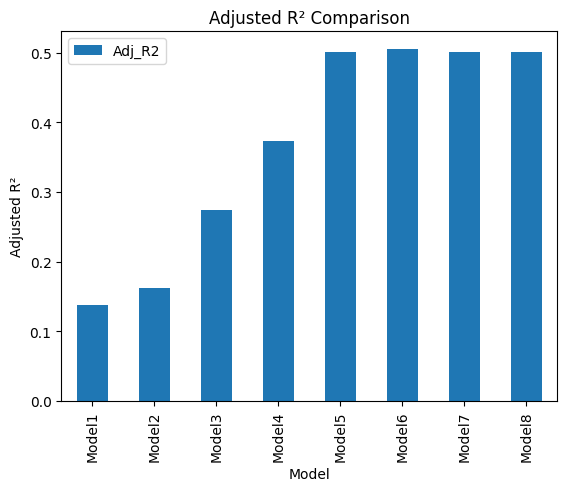

In [ ]:
comparison.plot(
    x="Model",
    y="Adj_R2",
    kind="bar"
)

plt.title("Adjusted R² Comparison")

plt.ylabel("Adjusted R²")

plt.show()